<h1><li>Online Course Recommendation</li></h1>

<h3>Required Libraries </h3>

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [2]:
df=pd.read_excel(r"C:\Users\anish\OneDrive\Desktop\Online Course Recommendation\online_course_recommendation_v2.xlsx")

In [3]:
df

,user_id,course_id,course_name,instructor,course_duration_hours,certification_offered,difficulty_level,rating,enrollment_numbers,course_price,feedback_score,study_material_available,time_spent_hours,previous_courses_taken
0,15796,9366,Python for Beginners,Emma Harris,39.1,Yes,Beginner,5.0,21600,317.50,0.797,Yes,17.60,4
1,861,1928,Cybersecurity for Professionals,Alexander Young,36.3,Yes,Beginner,4.3,15379,40.99,0.770,Yes,28.97,9
2,38159,9541,DevOps and Continuous Deployment,Dr. Mia Walker,13.4,Yes,Beginner,3.9,6431,380.81,0.772,Yes,52.44,4
3,44733,3708,Project Management Fundamentals,Benjamin Lewis,58.3,Yes,Beginner,3.1,48245,342.80,0.969,No,22.29,6
4,11285,3361,Ethical Hacking Masterclass,Daniel White,30.8,Yes,Beginner,2.8,34556,381.01,0.555,Yes,22.01,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99995,10647,5466,Graphic Design with Canva,Emma Harris,17.3,Yes,Beginner,3.9,49101,485.34,0.838,Yes,16.35,3
99996,13800,2623,Stock Market and Trading Strategies,Dr. John Smith,68.4,Yes,Beginner,3.5,35107,162.80,0.922,Yes,41.94,7
99997,47131,1556,Networking and System Administration,Dr. John Smith,73.8,Yes,Beginner,4.3,12146,24.02,0.990,Yes,15.87,5
99998,49654,6001,Graphic Design with Canva,Daniel White,30.3,Yes,Beginner,3.5,9933,402.24,0.630,Yes,21.05,4


<h4>Basic overview</h4>

In [4]:
print("Shape of dataset:", df.shape)
print("\nFirst 5 rows:\n", df.head())
print("\nDataset Info:\n")
df.info()



Shape of dataset: (100000, 14)

First 5 rows:
    user_id  course_id                       course_name       instructor  \
0    15796       9366              Python for Beginners      Emma Harris   
1      861       1928   Cybersecurity for Professionals  Alexander Young   
2    38159       9541  DevOps and Continuous Deployment   Dr. Mia Walker   
3    44733       3708   Project Management Fundamentals   Benjamin Lewis   
4    11285       3361       Ethical Hacking Masterclass     Daniel White   

   course_duration_hours certification_offered difficulty_level  rating  \
0                   39.1                   Yes         Beginner     5.0   
1                   36.3                   Yes         Beginner     4.3   
2                   13.4                   Yes         Beginner     3.9   
3                   58.3                   Yes         Beginner     3.1   
4                   30.8                   Yes         Beginner     2.8   

   enrollment_numbers  course_price  feedback

<h4> Check for missing values</h4>

In [5]:
print("\nMissing Values:\n", df.isnull().sum())



Missing Values:
 user_id                     0
course_id                   0
course_name                 0
instructor                  0
course_duration_hours       0
certification_offered       0
difficulty_level            0
rating                      0
enrollment_numbers          0
course_price                0
feedback_score              0
study_material_available    0
time_spent_hours            0
previous_courses_taken      0
dtype: int64


<h4> Summary statistics</h4>

In [6]:
print("\nSummary Statistics:\n", df.describe(include='all'))



Summary Statistics:
               user_id      course_id                           course_name  \
count   100000.000000  100000.000000                                100000   
unique            NaN            NaN                                    20   
top               NaN            NaN  Networking and System Administration   
freq              NaN            NaN                                  5107   
mean     24935.663570    5006.863560                                   NaN   
std      14406.960108    2882.085456                                   NaN   
min          1.000000       1.000000                                   NaN   
25%      12487.750000    2523.000000                                   NaN   
50%      24793.500000    5012.000000                                   NaN   
75%      37382.250000    7502.000000                                   NaN   
max      49999.000000    9999.000000                                   NaN   

              instructor  course_duration

<h4>Value counts for categorical features</h4>

In [7]:
categorical_cols = ['certification_offered', 'difficulty_level', 'study_material_available']
for col in categorical_cols:
    print(f"\nValue Counts for {col}:\n", df[col].value_counts())


Value Counts for certification_offered:
 certification_offered
Yes    70059
No     29941
Name: count, dtype: int64

Value Counts for difficulty_level:
 difficulty_level
Beginner        49877
Intermediate    29899
Advanced        20224
Name: count, dtype: int64

Value Counts for study_material_available:
 study_material_available
Yes    85147
No     14853
Name: count, dtype: int64


<h4>Rating Distribution</h4>

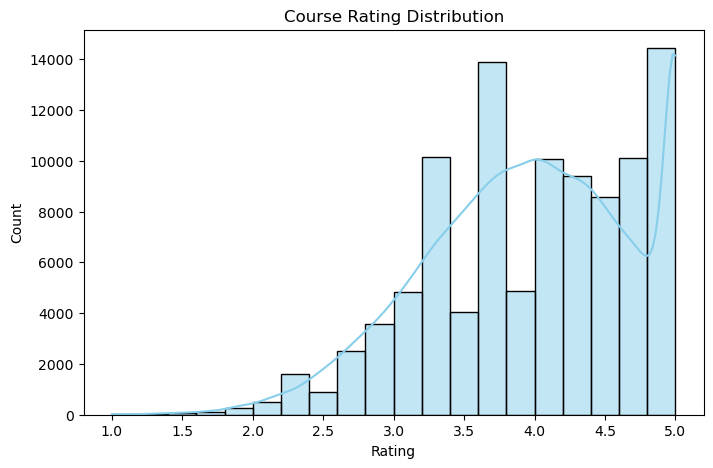

In [8]:
plt.figure(figsize=(8, 5))
sns.histplot(df['rating'], bins=20, kde=True, color='skyblue')
plt.title('Course Rating Distribution')
plt.xlabel('Rating')
plt.ylabel('Count')
plt.show()



<h4>Course Duration v/s Rating</h4>

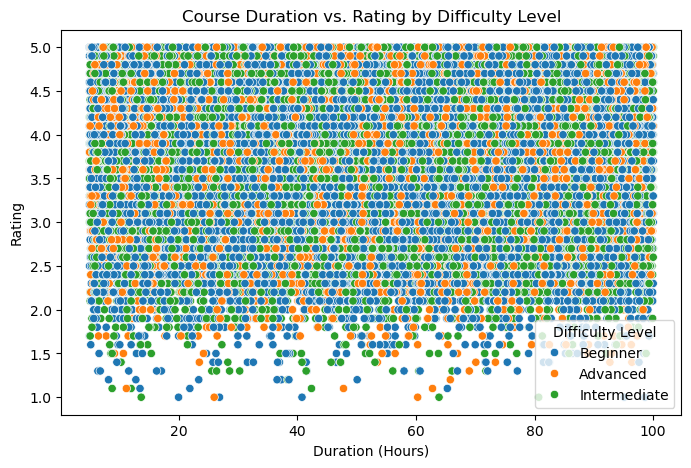

In [9]:
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x='course_duration_hours', y='rating', hue='difficulty_level')
plt.title('Course Duration vs. Rating by Difficulty Level')
plt.xlabel('Duration (Hours)')
plt.ylabel('Rating')
plt.legend(title='Difficulty Level')
plt.show()



<h4> Price v/s Enrollment</h4>

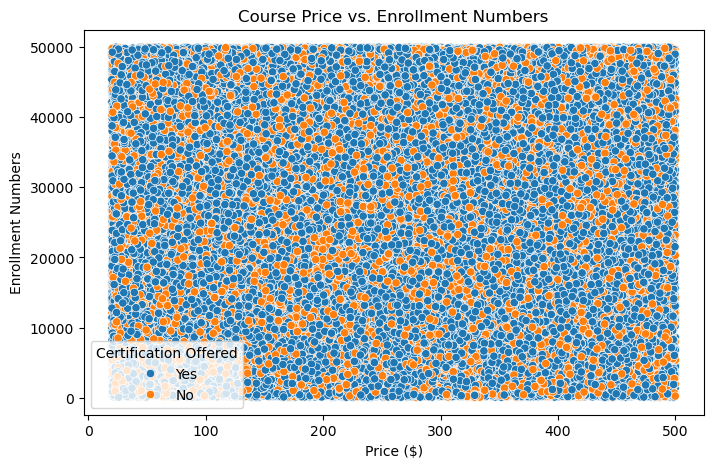

In [10]:
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x='course_price', y='enrollment_numbers', hue='certification_offered')
plt.title('Course Price vs. Enrollment Numbers')
plt.xlabel('Price ($)')
plt.ylabel('Enrollment Numbers')
plt.legend(title='Certification Offered')
plt.show()



<h4> Feedback Score Distribution</h4>

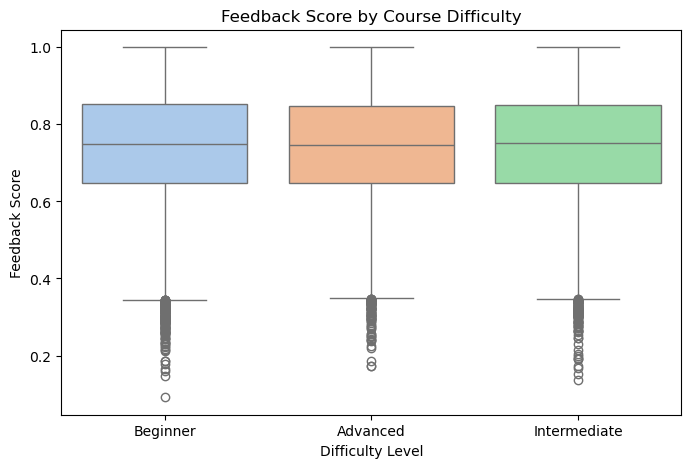

In [11]:

plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='difficulty_level', y='feedback_score', palette='pastel')
plt.title('Feedback Score by Course Difficulty')
plt.xlabel('Difficulty Level')
plt.ylabel('Feedback Score')
plt.show()



<h4>Correlation Matrix For Numerical Features</h4>

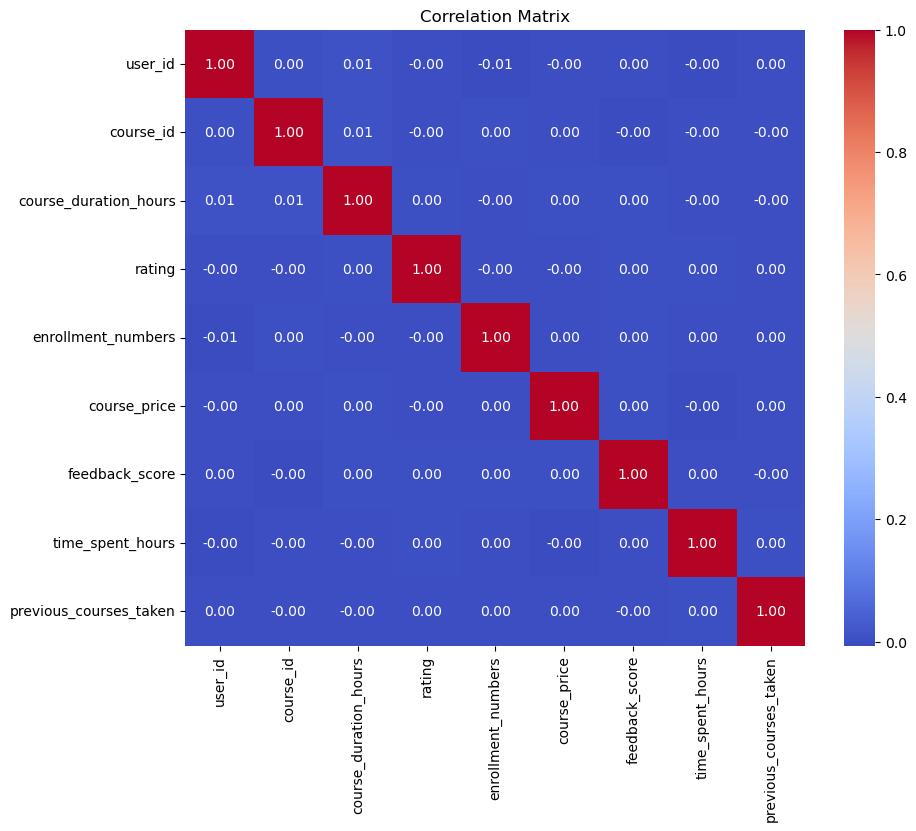

In [12]:

plt.figure(figsize=(10, 8))
numerical_cols = df.select_dtypes(include=['float64', 'int64']).columns
sns.heatmap(df[numerical_cols].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix')
plt.show()


<h4>Pairplot visualisation of Online Course Recommendation</h4>

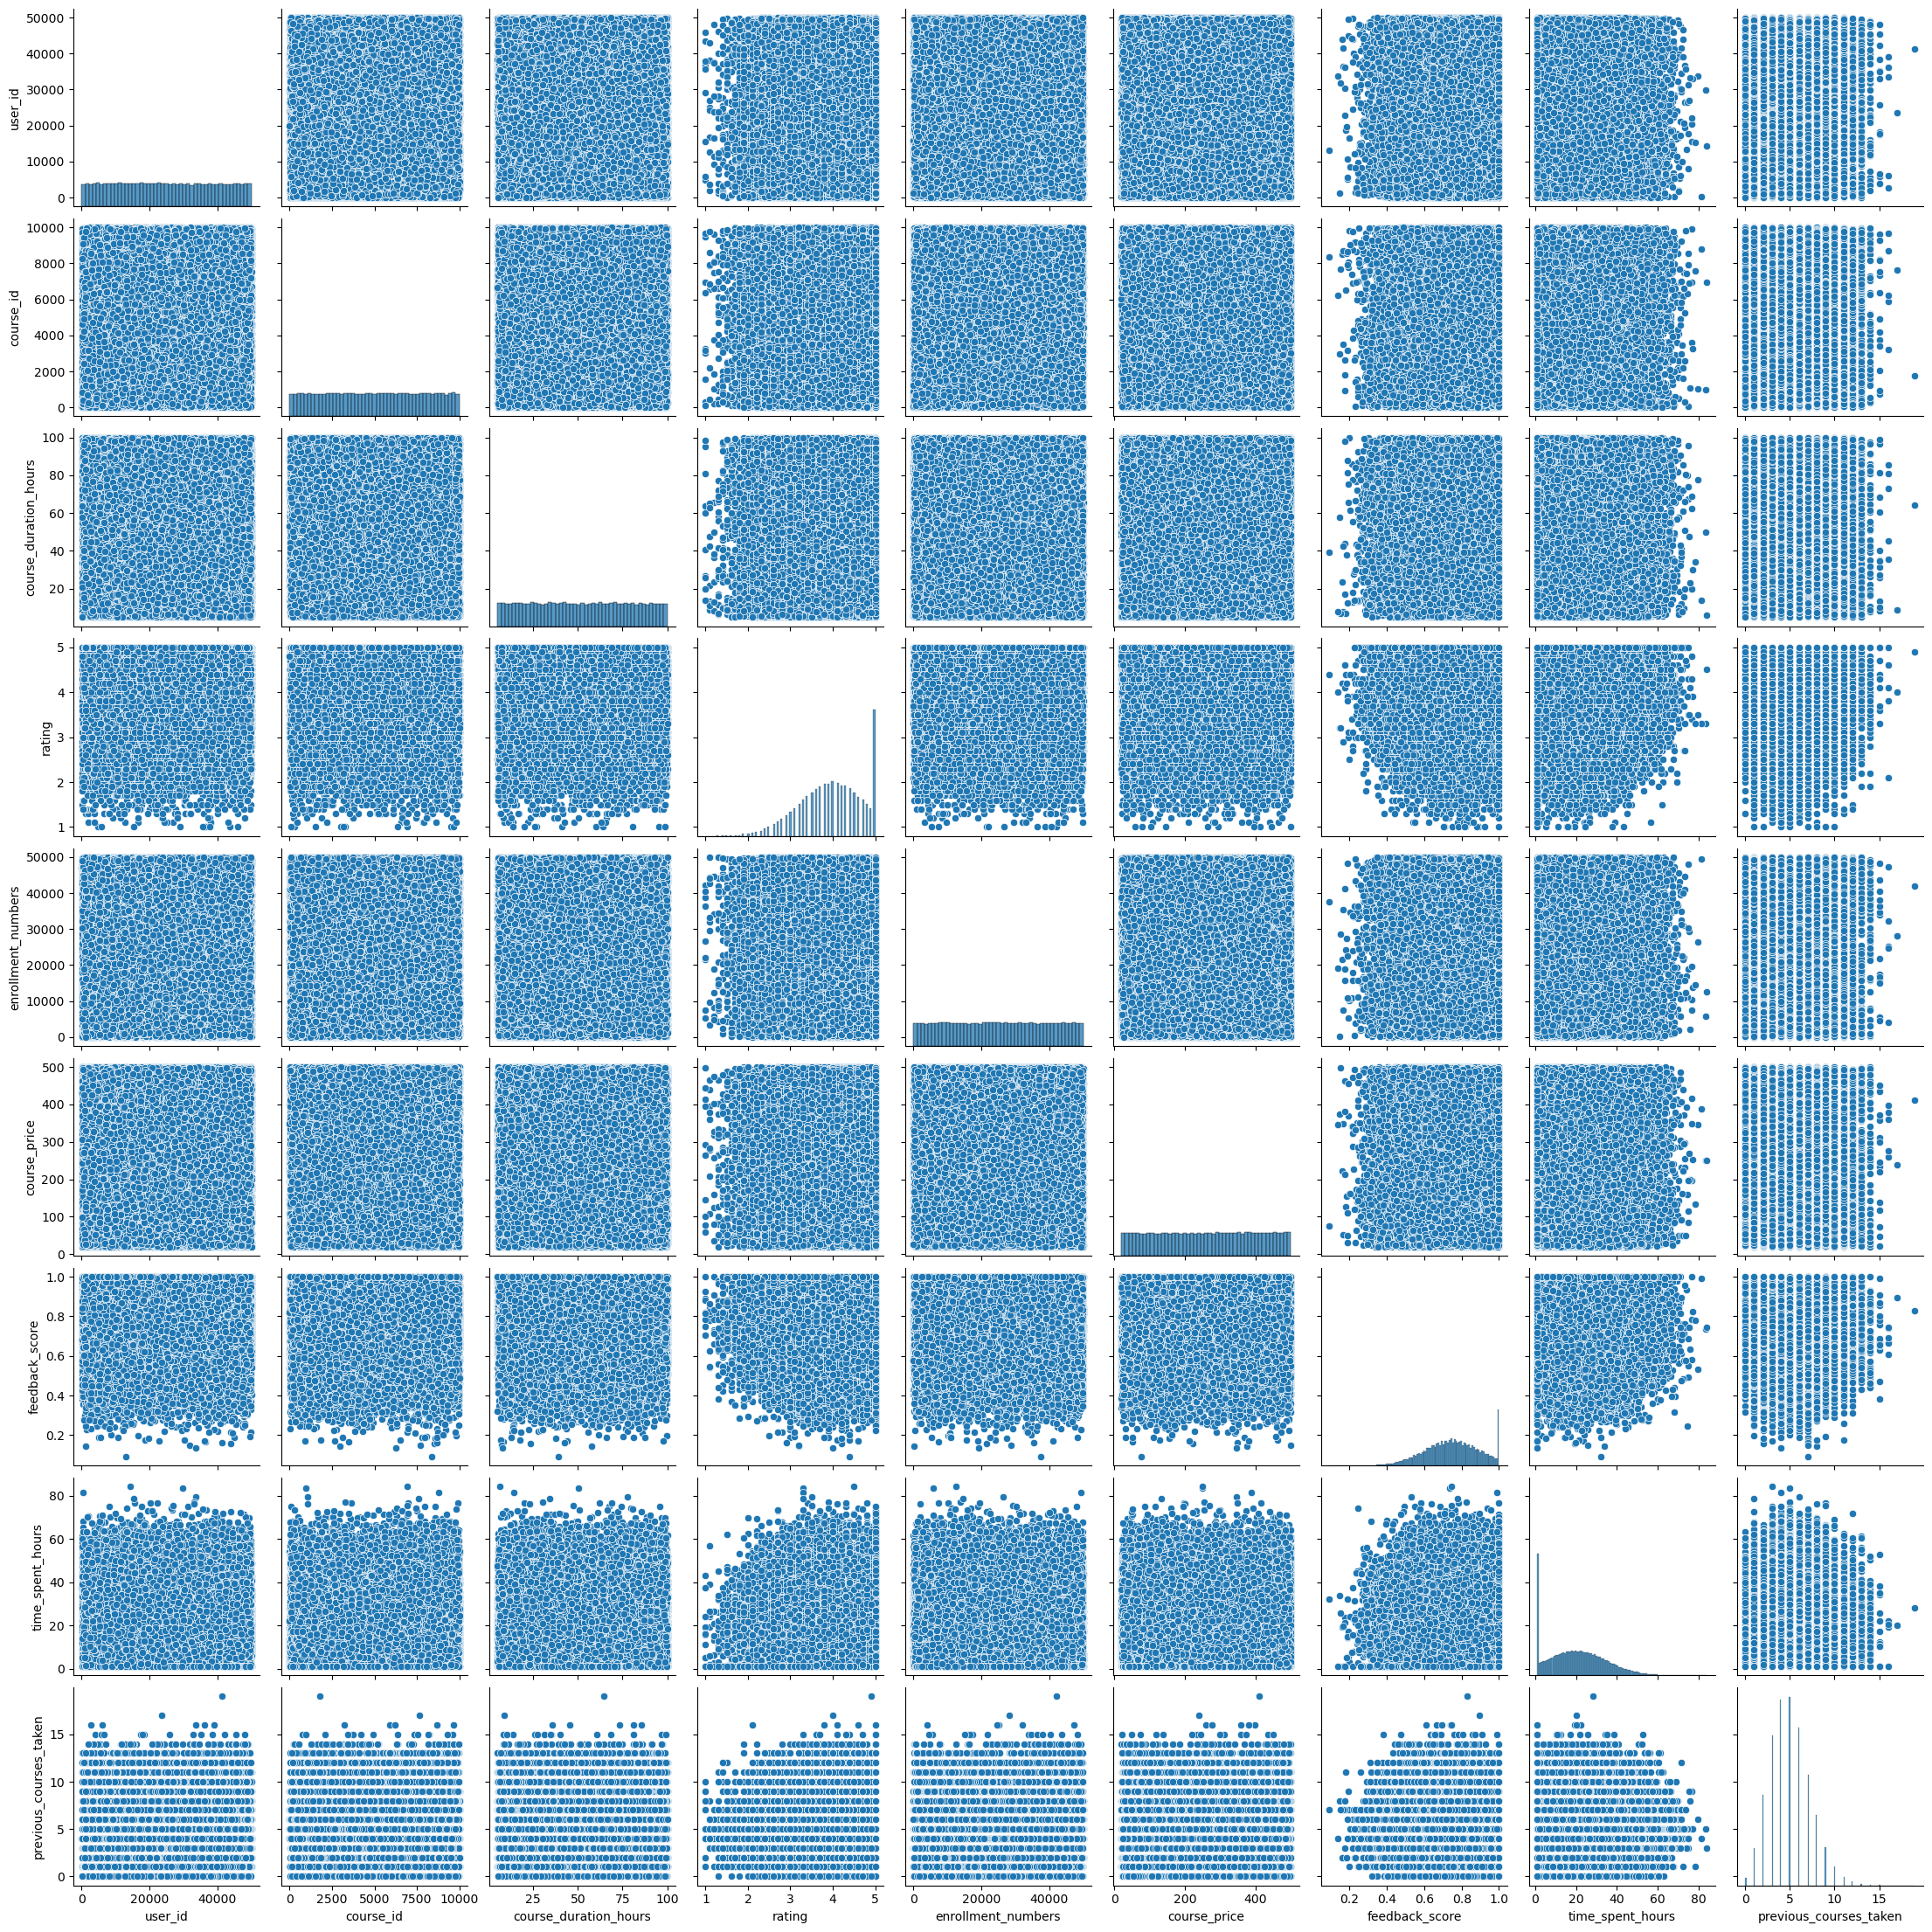

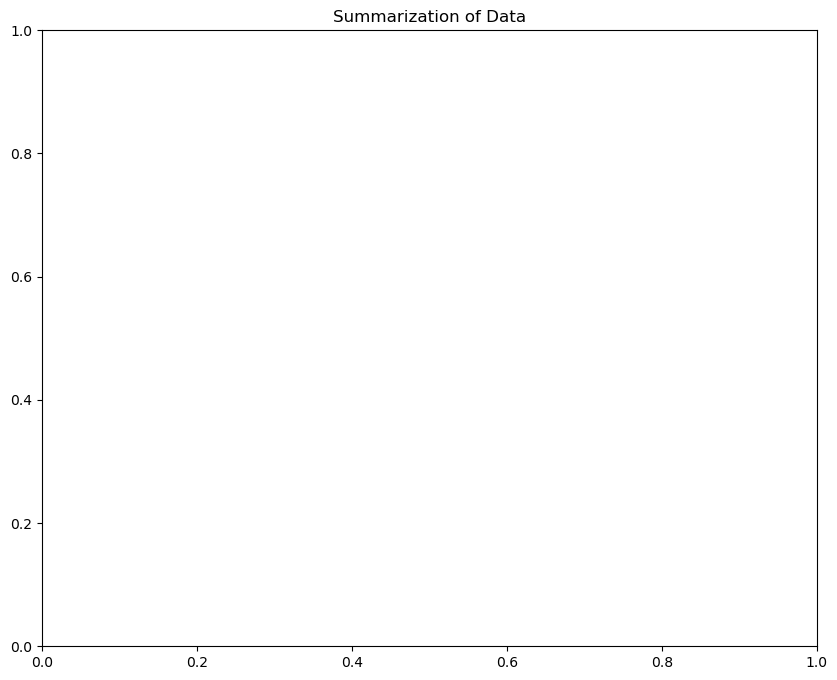

In [13]:
sns.pairplot(df)
plt.figure(figsize=(10,8))
plt.title('Summarization of Data')
plt.show()

In [14]:
#pip install wordcloud matplotlib pandas openpyxl


Note: you may need to restart the kernel to use updated packages.


<h4>Word Cloud Visualization Of Online Course Recommendations </h4>

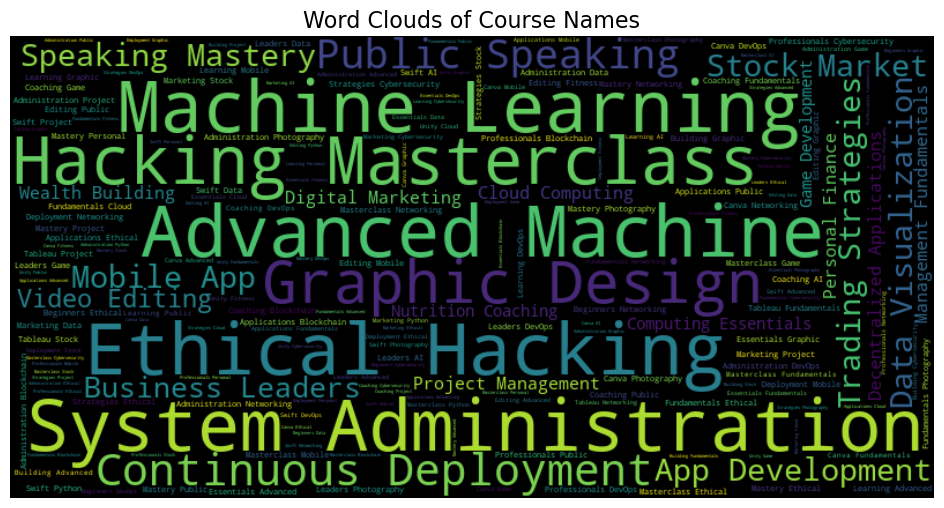

In [15]:
from wordcloud import WordCloud


# Combine all course names into one string
text = ' '.join(df['course_name'].dropna().astype(str))

# Create the word cloud
wordcloud = WordCloud(
    width=800,
    height=400,
    background_color='black',
    colormap='viridis',
    max_words=200
).generate(text)

# Display the word cloud
plt.figure(figsize=(12, 6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Word Clouds of Course Names', fontsize=16)
plt.show()


In [16]:
# Count the occurrences of each difficulty level
difficulty_counts = df['difficulty_level'].value_counts()


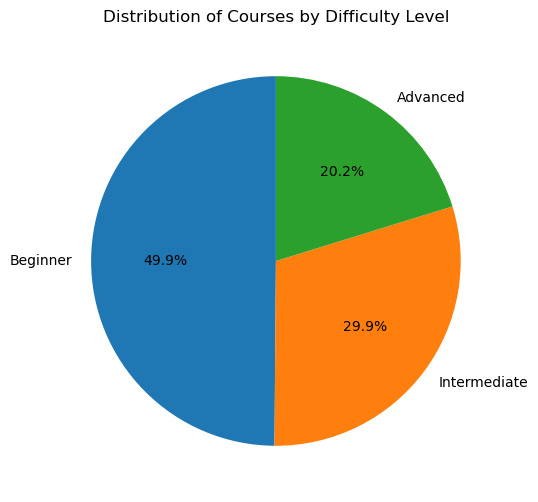

<Figure size 640x480 with 0 Axes>

In [17]:
# Create the pie chart
plt.figure(figsize=(8, 6))  # Adjust figure size if needed
plt.pie(difficulty_counts, labels=difficulty_counts.index, autopct='%1.1f%%', startangle=90)
plt.title('Distribution of Courses by Difficulty Level')
plt.show()
# Save the pie chart to a file (e.g., PNG format)
plt.savefig('difficulty_level_pie_chart.png')

<h4>MODEL BULIDING</h4>

<h5> USER COURSE INTERACTION MATRIX </H5>

In [24]:
interaction_matrix = df.pivot_table(index='user_id', columns='course_id', values='rating')
sparsity = 1.0 - (interaction_matrix.count().sum() / (interaction_matrix.shape[0] * interaction_matrix.shape[1]))
print(f"Sparsity of User-Course Matrix: {sparsity:.2%}")

Sparsity of User-Course Matrix: 99.98%


<h4>Scaling</h4>

In [18]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.metrics.pairwise import cosine_similarity


In [19]:
# Encode categorical variables
le = LabelEncoder()
df['course_name_enc'] = le.fit_transform(df['course_name'])
df['instructor_enc'] = le.fit_transform(df['instructor'])
df['difficulty_enc'] = le.fit_transform(df['difficulty_level'])
df['material_enc'] = le.fit_transform(df['study_material_available'])



In [20]:
# Normalize numeric features
scaler = MinMaxScaler()
features_to_scale = ['course_duration_hours', 'course_price', 'rating',
                     'feedback_score', 'time_spent_hours', 'previous_courses_taken', 'enrollment_numbers']
df[features_to_scale] = scaler.fit_transform(df[features_to_scale])


<h5> POPULARITY BASED RECOMMENDATION</H5>

In [21]:
# Popularity-Based Recommendation
def get_popular_courses(df, top_n=5):
    top_courses = df.sort_values(by='enrollment_numbers', ascending=False)
    return top_courses[['course_name', 'enrollment_numbers']].head(top_n)


<H5>Content-Based Filtering </H5>

In [22]:
# Content-Based Filtering
def get_similar_courses_based_on_input(enrollment, interest, engagement, top_n=5):
    # Create a dummy input vector
    user_input = pd.DataFrame([[enrollment, interest, engagement]],
                              columns=['enrollment_numbers', 'previous_courses_taken', 'time_spent_hours'])
    # Scale user input to match dataset scale
    scaler_input = MinMaxScaler()
    temp = df[['enrollment_numbers', 'previous_courses_taken', 'time_spent_hours']]
    scaler_input.fit(temp)
    user_input_scaled = scaler_input.transform(user_input)

    # Calculate cosine similarity between input and existing courses
    data_scaled = scaler_input.transform(temp)
    similarities = cosine_similarity(user_input_scaled, data_scaled).flatten()
    top_indices = similarities.argsort()[-top_n:][::-1]

    return df.iloc[top_indices][['course_id', 'course_name', 'enrollment_numbers', 'rating']]


<H5> Recommendation Based on Existing Enrollment IDs </H5>

In [26]:
#Recommendation Based on Existing Enrollment IDs

def recommend_based_on_enrollment_ids(enrollment_ids):
    print("Top 5 Popular Courses:")
    print(get_popular_courses(df))

    print("\nPersonalized Recommendations for Enrollment IDs")
    for eid in enrollment_ids:
        if eid in df['course_id'].values:
            course_row = df[df['course_id'] == eid][['enrollment_numbers', 'previous_courses_taken', 'time_spent_hours']].iloc[0]
            enrollment, interest, engagement = course_row
            print(f"\nBased on course ID {eid}:")
            print(get_similar_courses_based_on_input(enrollment, interest, engagement))
        else:
            print(f"\nEnrollment ID {eid} not found in dataset.")

# Example usage with enrollment IDs
sample_enrollment_ids = [101,205,309 ]  # Replace with real course IDs from your dataset
recommend_based_on_enrollment_ids(sample_enrollment_ids)


Top 5 Popular Courses:
                                course_name  enrollment_numbers
78898     Mobile App Development with Swift             1.00000
59090        Fitness and Nutrition Coaching             1.00000
12428  Personal Finance and Wealth Building             1.00000
77953     Fundamentals of Digital Marketing             1.00000
31804  Personal Finance and Wealth Building             0.99996

Personalized Recommendations for Enrollment IDs

Based on course ID 101:
       course_id                        course_name  enrollment_numbers  \
916          101               Python for Beginners            0.834711   
42166       4787          Advanced Machine Learning            0.695690   
7752        2603               Python for Beginners            0.417426   
91172       3350  Mobile App Development with Swift            0.835032   
61798       9635  Mobile App Development with Swift            0.835072   

       rating  
916     0.800  
42166   0.750  
7752    0.775  
9117

In [ ]:

#from sklearn.model_selection import train_test_split
#from sklearn.preprocessing import LabelEncoder, StandardScaler
#from sklearn.linear_model import LogisticRegression
#from sklearn.tree import DecisionTreeClassifier
#from sklearn.ensemble import RandomForestClassifier
#from sklearn.metrics import classification_report
#from sklearn.neighbors import KNeighborsClassifier  # Import KNN
#from xgboost import XGBClassifier  # Import XGBoost
#from sklearn.metrics import classification_report
#from sklearn.metrics import confusion_matrix, accuracy_score
#from sklearn.metrics import f1_score, classification_report, precision_score, recall_score
#from sklearn.svm import SVC
#from sklearn.ensemble import BaggingClassifier
#from sklearn.ensemble import AdaBoostClassifier
#from sklearn.ensemble import GradientBoostingClassifier

In [ ]:
# Assuming 'df' is your DataFrame
# Select features for X and target for y
# Example:
# Create a LabelEncoder object
label_encoder = LabelEncoder()

X = df[['course_duration_hours', 'course_price', 'enrollment_numbers', 'feedback_score']]  # Replace with your desired features
y = df['difficulty_level']  # Replace with your desired target variable



In [ ]:
# Assuming you have already created df_model, X, and y as described in the previous response

# Split data into training and testing sets
#X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [ ]:
# Scale numerical features (optional but recommended for some models)
#scaler = StandardScaler()
#X_train = scaler.fit_transform(X_train)
#X_test = scaler.transform(X_test)


#<h5>1. LOGISTIC REGRESSION</h5>

In [ ]:
#logreg_model = LogisticRegression()
#logreg_model.fit(X_train, y_train)
#logreg_predictions = logreg_model.predict(X_test)
#logreg_accuracy = accuracy_score(y_test,logreg_predictions)
#print('Accuracy of training set : {:.2f}'.format(logreg_model.score(X_train, y_train)))
#print('Accuracy of testing set : {:.2f}'.format(logreg_model.score(X_test, y_test)))
#print("Logistic Regression Classification Report:\n", classification_report(y_test, logreg_predictions))

#logreg_precision=round(precision_score(y_test,logreg_predictions,average = 'macro'),2)
#logreg_recall=round(recall_score(y_test,logreg_predictions, average = 'macro'),2)
#logreg_f1= round(f1_score(y_test,logreg_predictions, average = 'macro'),2)
#logreg_accuracy= round(accuracy_score(y_test,logreg_predictions),2)

<h5>2. DECISION TREE</h5>

In [ ]:
#tree_model = DecisionTreeClassifier()
#tree_model.fit(X_train, y_train)
#tree_predictions = tree_model.predict(X_test)
#tree_accuracy= accuracy_score(y_test,tree_predictions)
#print('Accuracy of training set : {:.2f}'.format(tree_model.score(X_train, y_train)))
#print('Accuracy of  test set    : {:.2f}'.format(tree_model.score(X_test, y_test)))
#print("Decision Tree Classification Report:\n", classification_report(y_test, tree_predictions))

#tree_model_precision= round(precision_score(y_test,tree_predictions,average = 'macro'),2)
#tree_model_recall= round(recall_score(y_test,tree_predictions, average = 'macro'),2)
#tree_model_f1= round(f1_score(y_test,tree_predictions, average = 'macro'),2)
#tree_model_accuracy=  round(accuracy_score(y_test,tree_predictions),2)

<H5>3. RANDOM FOREST</H5>

In [ ]:
#forest_model = RandomForestClassifier()
#forest_model.fit(X_train, y_train)
#forest_predictions = forest_model.predict(X_test)
#forest_accuracy= accuracy_score(y_test, forest_predictions)
#print('Accuracy of training set : {:.2f}'.format(forest_model.score(X_train, y_train)))
#print('Accuracy of  test set    : {:.2f}'.format(forest_model.score(X_test, y_test)))
#print("Random Forest Classification Report:\n", classification_report(y_test, forest_predictions))

#forest_precision= round(precision_score(y_test,forest_predictions,average = 'macro'),2)
#forest_recall= round(recall_score(y_test,forest_predictions, average = 'macro'),2)
#forest_f1= round(f1_score(y_test,forest_predictions, average = 'macro'),2)
#forest_accuracy= round(accuracy_score(y_test,forest_predictions),2)

<H5>4. K-NEAREST NEIGHBORS (KNN)</H5>

In [ ]:
#knn_model = KNeighborsClassifier(n_neighbors=5)  # You can adjust n_neighbors
#knn_model.fit(X_train, y_train)
#knn_predictions = knn_model.predict(X_test)
#knn_accuracy= accuracy_score(y_test,knn_predictions)
#print('Accuracy of training set : {:.2f}'.format(knn_model.score(X_train, y_train)))
#print('Accuracy of  test set    : {:.2f}'.format(knn_model.score(X_test, y_test)))
#print("KNN Classification Report:\n", classification_report(y_test, knn_predictions))

#knn_precision= round(precision_score(y_test,knn_predictions,average = 'macro'),2)
#knn_recall= round(recall_score(y_test,knn_predictions, average = 'macro'),2)
#knn_f1= round(f1_score(y_test,knn_predictions, average = 'macro'),2)
#knn_accuracy= round(accuracy_score(y_test,knn_predictions),2)


<H5>5. XGBOOST </H5>

In [ ]:
# Import LabelEncoder
#from sklearn.preprocessing import LabelEncoder

# Create a LabelEncoder object
#label_encoder = LabelEncoder()

# Fit the encoder to your target variable and transform it
#y_train_encoded = label_encoder.fit_transform(y_train)
#y_test_encoded = label_encoder.transform(y_test)  # Use the same encoder for the test set

# Now use the encoded target variables for training and prediction
#xgb_model = XGBClassifier()
#xgb_model.fit(X_train, y_train_encoded)  # Use y_train_encoded here
#xgb_predictions = xgb_model.predict(X_test)
#xgb_accuracy=  accuracy_score(y_test_encoded,xgb_predictions)
# Convert predictions back to original labels
#predicted_labels = label_encoder.inverse_transform(xgb_predictions)

#print('Accuracy of training set : {:.2f}'.format(xgb_model.score(X_train, y_train_encoded)))
#print('Accuracy of  test set    : {:.2f}'.format(xgb_model.score(X_test, y_test_encoded)))
#print("XGBoost Classification Report:\n", classification_report(y_test_encoded, xgb_predictions)) # Use y_test_encoded here

#xgb_precision= round(precision_score(y_test,predicted_labels,average = 'macro'),2)
#xgb_recall= round(recall_score(y_test,predicted_labels, average = 'macro'),2)
#xgb_f1= round(f1_score(y_test,predicted_labels, average = 'macro'),2)
#xgb_accuracy= round(accuracy_score(y_test,predicted_labels),2)

<h5>6. SUPPORT VECTOR MACHINE</h5>

In [ ]:
#svm_model= SVC()
#svm_model.fit(X_train,y_train)
#svm_predictions= svm_model.predict(X_test)
#svm_accuracy = accuracy_score(y_test, svm_predictions)
#print('Accuracy of training set : {:.2f}'.format(svm_model.score(X_train,y_train)))
#print('Accuracy of  test set    : {:.2f}'.format(svm_model.score(X_test,y_test)))
#print("Classification report for classifier %s:\n%s\n" % (svm_model,classification_report(y_test,svm_predictions)))

#svm_precision = round(precision_score(y_test,svm_predictions,average = 'macro'),2)
#svm_recall= round(recall_score(y_test,svm_predictions, average = 'macro'),2)
#svm_f1 = round(f1_score(y_test,svm_predictions, average = 'macro'),2)
#svm_accuracy = round(accuracy_score(y_test,svm_predictions),2)

<h5>7. Bagging Classifier</h5>

In [ ]:
#bagg_model= BaggingClassifier(KNeighborsClassifier(), max_samples=0.5, max_features=0.5)
#bagg_model.fit(X_train,y_train)
#bagg_predictions= bagg_model.predict(X_test)
#bagg_accuracy = accuracy_score(y_test, bagg_predictions)
#print('Accuracy of training set : {:.2f}'.format(bagg_model.score(X_train,y_train)))
#print('Accuracy of  test set    : {:.2f}'.format(bagg_model.score(X_test,y_test)))
#print("Classification report for  %s:\n%s\n" % (bagg_model,classification_report(y_test,bagg_predictions)))

#bagg_precision = round(precision_score(y_test,bagg_predictions,average = 'macro'),2)
#bagg_recall= round(recall_score(y_test,bagg_predictions, average = 'macro'),2)
#bagg_f1 = round(f1_score(y_test,bagg_predictions, average = 'macro'),2)
#bagg_accuracy = round(accuracy_score(y_test,bagg_predictions),2)

<h5>8. Ada Boost Classifier</h5>

In [ ]:
#adaboost_model = AdaBoostClassifier(n_estimators=100)
#adaboost_model.fit(X_train, y_train)
#adaboost_predictions = adaboost_model.predict(X_test)
#adaboost_accuracy = accuracy_score(y_test,adaboost_predictions)
#print('Accuracy of training set : {:.2f}'.format(adaboost_model.score(X_train, y_train)))
#print('Accuracy of  test set    : {:.2f}'.format(adaboost_model.score(X_test, y_test)))
#print("Classification report for classifier %s:\n%s\n" % (adaboost_model,classification_report(y_test, adaboost_predictions)))


#adaboost_precision = round(precision_score(y_test,adaboost_predictions,average = 'macro'),2)
#adaboost_recall = round(recall_score(y_test,adaboost_predictions, average = 'macro'),2)
#adaboost_f1 = round(f1_score(y_test,adaboost_predictions, average = 'macro'),2)
#adaboost_accuracy = round(accuracy_score(y_test,adaboost_predictions),2)

<h5>9. Gradient Boosting Classifier</h5>

In [ ]:
#gradboost_model = GradientBoostingClassifier(n_estimators=100,learning_rate=1.0,max_depth=1, random_state=0)
#gradboost_model.fit(X_train, y_train)
#gradboost_predictions = gradboost_model.predict(X_test)
#gradboost_accuracy = accuracy_score(y_test,gradboost_predictions )
#print('Accuracy of training set : {:.2f}'.format(gradboost_model.score(X_train, y_train)))
#print('Accuracy of  test set    : {:.2f}'.format(gradboost_model.score(X_test, y_test)))
#print("Classification report for  %s:\n%s\n" % (gradboost_model,classification_report(y_test, gradboost_predictions)))


#gradboost_precision = round(precision_score(y_test,gradboost_predictions,average = 'macro'),2)
#gradboost_recall= round(recall_score(y_test,gradboost_predictions, average = 'macro'),2)
#gradboost_f1= round(f1_score(y_test,gradboost_predictions, average = 'macro'),2)
#gradboost_accuracy = round(accuracy_score(y_test,gradboost_predictions),2)

In [ ]:
#Evaluation= {"Models":["Logistic Regression","DecisionTree Classifier","RandomForest Classifier", "KNN Classifier","XGBoost Classifier",
                       "Support Vector Machine","Bagging Classifier","Ada Boost CLassifier","Gradient Boosting"],\
             "Train_Accuracy(%)":[logreg_model.score(X_train, y_train),tree_model.score(X_train, y_train),
                                  forest_model.score(X_train, y_train),knn_model.score(X_train, y_train),
                                  xgb_model.score(X_train, y_train_encoded),svm_model.score(X_train,y_train),
                                  bagg_model.score(X_train,y_train),adaboost_model.score(X_train, y_train),
                                  gradboost_model.score(X_train, y_train)],
            "Test_Accuracy(%)":[logreg_accuracy,tree_accuracy,forest_accuracy,knn_accuracy,
                                xgb_accuracy,svm_accuracy,bagg_accuracy,adaboost_accuracy,gradboost_accuracy],\
            "Precision(%)":[logreg_precision,tree_model_precision,forest_precision,knn_precision,
                            xgb_precision,svm_precision,bagg_precision,adaboost_precision,gradboost_precision],\
            "Recall(%)":[logreg_f1,tree_model_f1,forest_f1,knn_f1,xgb_f1,svm_f1,bagg_f1,adaboost_f1,gradboost_f1]}
#table= pd.DataFrame(Evaluation)
#table

In [ ]:
#model_names=["Logistic Regression","DecisionTree Classifier","RandomForest Classifier",
             "KNN Classifier","XGBoost Classifier","Support Vector Classifier",
             "Bagging Classifier","Adaboost Classifier","Gradient Boosting"]
#Test_accuracies=[logreg_accuracy*100,tree_accuracy*100,forest_accuracy*100,
                 knn_accuracy*100,xgb_accuracy*100,svm_accuracy*100,
                 bagg_accuracy*100,adaboost_accuracy*100,gradboost_accuracy*100]
#Train_accuracies= [logreg_model.score(X_train, y_train)*100,tree_model.score(X_train, y_train)*100,
                                  forest_model.score(X_train, y_train)*100,knn_model.score(X_train, y_train)*100,
                                  xgb_model.score(X_train, y_train_encoded)*100,svm_model.score(X_train,y_train)*100,
                  bagg_model.score(X_train,y_train)*100,adaboost_model.score(X_train, y_train)*100,
                   gradboost_model.score(X_train, y_train)*100]

In [ ]:
#import matplotlib.pyplot as plt
#import numpy as np
#import matplotlib.pylab as pylab
#sns.set_style('darkgrid')
#%matplotlib inline

#rcParams = {'xtick.labelsize':'12','ytick.labelsize':'14','axes.labelsize':'16'}
#fig, axe = plt.subplots(1,1, figsize=(12,6), dpi=500)
#x_pos = np.arange(len(table))
#model_names = ["Logistic","Decision Tree","Random Forest","KNN","XGBoost","Support Vector","Bagging","Adaboost","Gradient Boosting"]

#bar1 = plt.bar(x_pos - 0.2, table['Train_Accuracy(%)'], width=0.4, label='Train', color= "Orange")
#bar2 = plt.bar(x_pos + 0.2, table['Test_Accuracy(%)'], width=0.4, label='Test', color= "b")
#plt.xticks(x_pos, model_names)

#plt.xlabel("Classifiers", fontsize = 16, fontweight = 'bold')
#plt.ylabel("Accuracy", fontsize = 16, fontweight = 'bold')
#plt.title("Model Accuracy Scores", fontsize = 18, fontweight = 'bold')
#plt.xticks(rotation = 10)
#plt.legend()

#for i, bar in enumerate(bar1):
    plt.text(bar.get_x() + bar.get_width()/2 - 0.1, bar.get_height()*1.02,
             s = '{:.2f}%'.format(Train_accuracies[i]), fontsize = 7)

#for i, bar in enumerate(bar2):
    plt.text(bar.get_x() + bar.get_width()/2 - 0.1, bar.get_height()*1.02,
             s = '{:.2f}%'.format(Test_accuracies[i]), fontsize = 7)

#pylab.rcParams.update(rcParams)
#fig.tight_layout()
#plt.show()


In [ ]:
# Assuming you have already created df_model, X, and y as described in the previous response

# Split data into training and testing sets
#X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scale numerical features
#scaler = StandardScaler()
#X_train = scaler.fit_transform(X_train)
#X_test = scaler.transform(X_test)

# Initialize and train models
#models = {
    "Logistic Regression": LogisticRegression(),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(),
    "KNN": KNeighborsClassifier(n_neighbors=5),
    "XGBoost": XGBClassifier(),
    "Support Vector Machine": SVC(),
    "Bagging Classifier": BaggingClassifier(KNeighborsClassifier(), max_samples=0.5, max_features=0.5),
    "AdaBoost Classifier": AdaBoostClassifier(n_estimators=100),
    "Gradient Classifier": GradientBoostingClassifier(n_estimators=100,learning_rate=1.0,max_depth=1, random_state=0)
    
    
}

# Encode target variable for XGBoost
#label_encoder = LabelEncoder()
#y_train_encoded = label_encoder.fit_transform(y_train)
#y_test_encoded = label_encoder.transform(y_test)

# Store results
#results = {}

# Train and evaluate each model
#for model_name, model in models.items():
    #if model_name == "XGBoost":
        #model.fit(X_train, y_train_encoded)
        #predictions = model.predict(X_test)
        #report = classification_report(y_test_encoded, predictions)
    #else:
        #model.fit(X_train, y_train)
        #predictions = model.predict(X_test)
        #report = classification_report(y_test, predictions)

    #results[model_name] = report


# Compare results
#for model_name, report in results.items():
    #print(f"--- {model_name} ---\n{report}\n")

# Print Summary:
#print("----Summary----")
#for model_name in models:
    #report = results[model_name]
    #accuracy = float(report.split('accuracy')[1].split()[0])
    3print(f"{model_name} Accuracy: {accuracy:.4f}")

# Find best model based on accuracy
#best_model_name = max(results, key=lambda k: float(results[k].split('accuracy')[1].split()[0]))
#print(f"\nBest model: {best_model_name}")